# Profitlens - Amazon Sales Analysis



### Business Questiones : 

1) What is the monthly revenue trend?
2) Which product category generates the most revenue?
3) What is the order fulfillment & cancellation rate?
4) Which states drive the most saales?
5) Which day of the week sees the most orders?
6) How are orders split between fulfillment methods and service levels?
7) How does revenue vary by category across months?
8) What is the B2B vs B2C split?
9) What does the order amount distribution look like?

## 1. Setup & Import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

PALETTE = ["#185FA5", "#1D9E75","#D85A30", "#534AB7", "#BA7517", "#993556", "#639922", "#E24B4A", "#888780"]
BG = "#FAFAF8"
BORDER = "#D3D1C7"

sns.set_theme(style="white", font="DejaVu Sans")
plt.rcParams.update({
    "axes.facecolor" : BG,
    "figure.facecolor" : BG,
    "axes.edgecolor" : BORDER,
    "axes.linewidth" : 0.6,
    "grid.color" : BORDER,
    "grid.linewidth" : 0.5,
    "axes.grid" : True,
    "axes.spines.top" : False,
    "axes.spines.right" : False,
    "font.size" : 11,
    "axes.titlesize" : 13,
    "axes.titleweight" : "500",
    "axes.labelsize" : 11,
})

print("Libraries loaded Successfully...")

Libraries loaded Successfully...


## 2. Loaded & Inspect the Dataset

In [2]:
df = pd.read_csv("E:/Python/profitlens/data/processed/amazon_sales_cleaned.csv")
df.columns = df.columns.str.strip()

print(f"Shape : {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)

Shape : 116,044 rows x 20 columns


,order_id,order_date,order_status,fulfillment,sales_channel,service_level,style,sku,category,product_size,asin,courier_status,quantity,currency,amount,city,state,postal_code,country,B2B
0,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.0,bengaluru,karnataka,560085.0,IN,False
1,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.0,navi mumbai,maharashtra,410210.0,IN,True
2,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.0,chennai,tamil nadu,600073.0,IN,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116044 entries, 0 to 116043
Data columns (total 20 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   order_id        116044 non-null  object 
 1   order_date      116044 non-null  object 
 2   order_status    116044 non-null  object 
 3   fulfillment     116044 non-null  object 
 4   sales_channel   116044 non-null  object 
 5   service_level   116044 non-null  object 
 6   style           116044 non-null  object 
 7   sku             116044 non-null  object 
 8   category        116044 non-null  object 
 9   product_size    116044 non-null  object 
 10  asin            116044 non-null  object 
 11  courier_status  116044 non-null  object 
 12  quantity        116044 non-null  int64  
 13  currency        116044 non-null  object 
 14  amount          116044 non-null  float64
 15  city            116044 non-null  object 
 16  state           116044 non-null  object 
 17  postal_cod

In [4]:
print("Null Values per Column : ")
print(df.isnull().sum()[df.isnull().sum()>0])
print()
print("Numeric Summary:")
df[["quantity", "amount"]].describe().round(2)

Null Values per Column : 
postal_code    28
dtype: int64

Numeric Summary:


,quantity,amount
count,116044.00,116044.00
mean,1.00,649.78
std,0.07,282.64
min,1.00,0.00
25%,1.00,449.00
50%,1.00,606.00
75%,1.00,788.00
max,8.00,5584.00


## 3. Data Preprocessing

In [5]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["month"] = df["order_date"].dt.to_period("M").astype(str)
df["month_name"] = df["order_date"].dt.strftime("%b %Y")
df["day_of_week"] = df["order_date"].dt.day_name()

df["status_clean"] = (df["order_status"].str.replace("Shipped - ", " ").str.replace("Pending - ", " "))

print("Date range: ", df["order_date"].min().date(), "→", df["order_date"].max().date())
print("Categories: ", df["category"].unique().tolist())
print("States: ", df["state"].nunique())

Date range:  2022-03-31 → 2022-06-29
Categories:  ['kurta', 'Top', 'Set', 'Western Dress', 'Ethnic Dress', 'Bottom', 'Saree', 'Blouse', 'Dupatta']
States:  47


## 4. Analysis & Visualizations

### 4.1 Monthly Revenue Trend

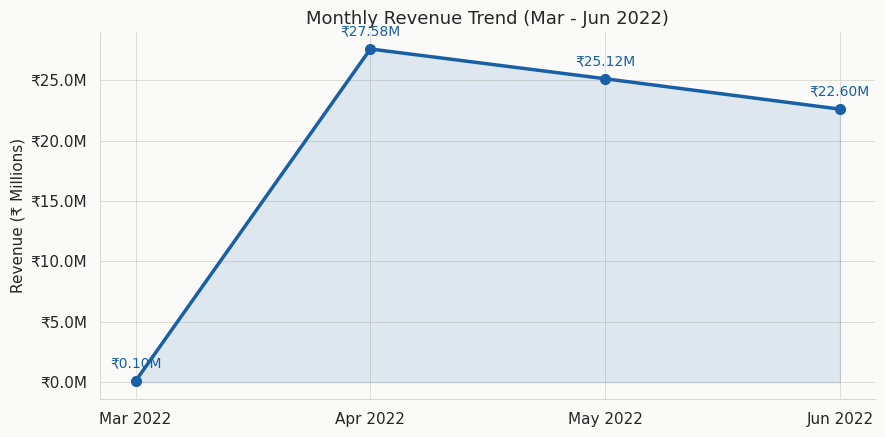


Insight: Revenue peaked in' Apr 2022 at ₹27.58M


In [19]:
monthly = (df.groupby("month")["amount"].sum().reset_index().sort_values("month"))
labels = ["Mar 2022", "Apr 2022", "May 2022", "Jun 2022"]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.fill_between(range(len(monthly)), monthly["amount"]/1e6, alpha=0.12, color=PALETTE[0])
ax.plot(range(len(monthly)), monthly['amount']/1e6,
        color=PALETTE[0], linewidth=2.5, marker='o', markersize=7)

for i, (_, row) in enumerate(monthly.iterrows()):
    ax.annotate(f"₹{row["amount"]/1e6:.2f}M", (i, row["amount"]/1e6), 
                textcoords= "offset points", xytext=(0,10),
                ha="center", fontsize = 10, color= PALETTE[0])
    
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(labels)
ax.set_title("Monthly Revenue Trend (Mar - Jun 2022)")
ax.set_ylabel("Revenue (₹ Millions)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"₹{x:.1f}M"))
plt.tight_layout()
plt.savefig("E:/Python/profitlens/src/output/amazon_sales/01_monthly_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nInsight: Revenue peaked in'", labels[monthly["amount"].idxmax()],
      f"at ₹{monthly['amount'].max()/1e6:.2f}M")

### 4.2 Revenue by Category

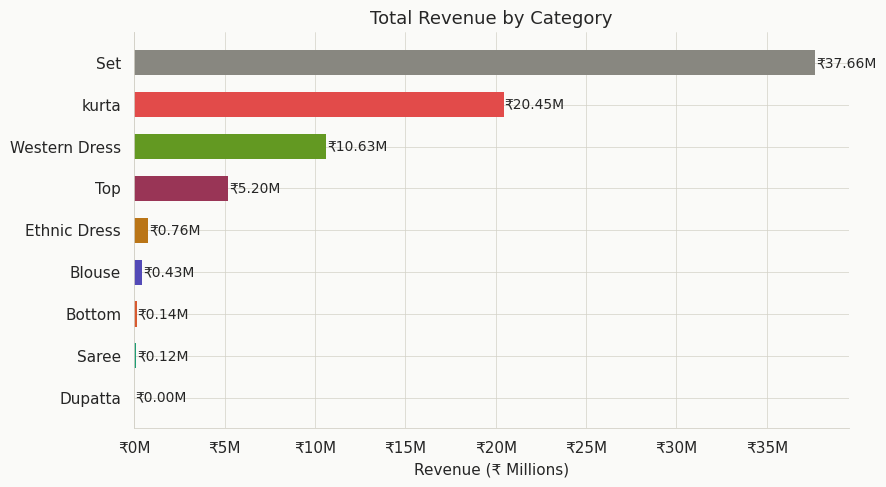


Insight: "Set" is the highest-revenue category at ₹37.66M


In [20]:
cat_rev = df.groupby("category")["amount"].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(cat_rev.index, cat_rev.values/1e6, color=PALETTE[:len(cat_rev)], height=0.6, edgecolor="none")

for bar, val in zip(bars, cat_rev.values):
    ax.text(val/1e6 + 0.05, bar.get_y() + bar.get_height()/2, f"₹{val/1e6:.2f}M", va="center", fontsize = 10)

ax.set_title("Total Revenue by Category")
ax.set_xlabel("Revenue (₹ Millions)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"₹{x:.0f}M"))
plt.tight_layout()
plt.savefig("E:/Python/profitlens/src/output/amazon_sales/02_revenue_by_category.png", dpi=150, bbox_inches = "tight")
plt.show()

top = cat_rev.index[-1]
print(f'\nInsight: "{top}" is the highest-revenue category at ₹{cat_rev.max()/1e6:.2f}M')

### 4.3 Order Status Distribution

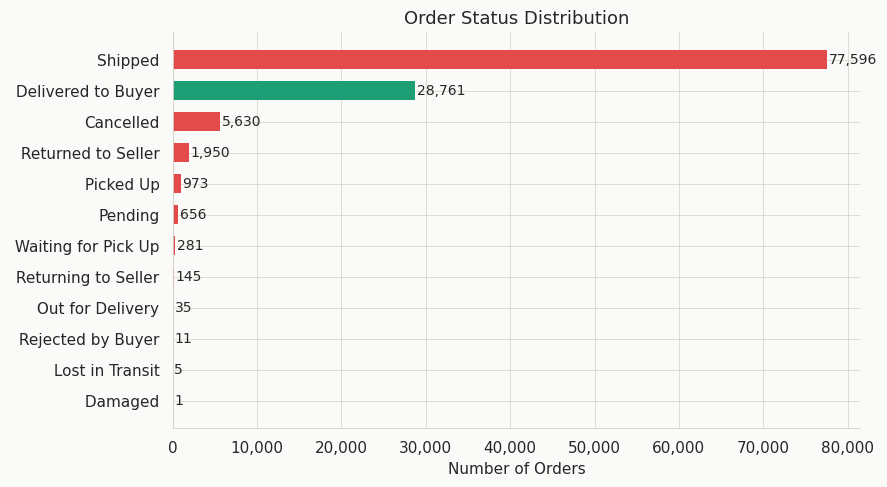

Delivery rate : 24.8%
Cancellation rate : 4.9%


In [21]:
status = df["status_clean"].value_counts()

def status_color(s):
    if "Delivered" in s: 
        return PALETTE[1]
    if any(x in s for x in ["Cancel", "Reject", "Lost", "Damage"]):
        return PALETTE[7]

    return PALETTE[7]
    
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(status.index[::-1], status.values[::-1],
               color = [status_color(i) for i in status.index[::-1]],
               height = 0.6, edgecolor = "none")

for bar, val in zip(bars, status.values[::-1]):
    ax.text(val+200, bar.get_y() + bar.get_height()/2, f"{val:,}", va="center", fontsize=10)

ax.set_title("Order Status Distribution")
ax.set_xlabel("Number of Orders")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("E:/Python/profitlens/src/output/amazon_sales/03_order_status.png", dpi=150, bbox_inches = "tight")
plt.show()

delivered = df["order_status"].str.contains("Delivered").sum()
cancelled = df["order_status"].str.contains("Cancelled").sum()
print(f"Delivery rate : {delivered/len(df)*100:.1f}%")
print(f"Cancellation rate : {cancelled/len(df)*100:.1f}%")

### 4.4 Top 10 states by Revenue

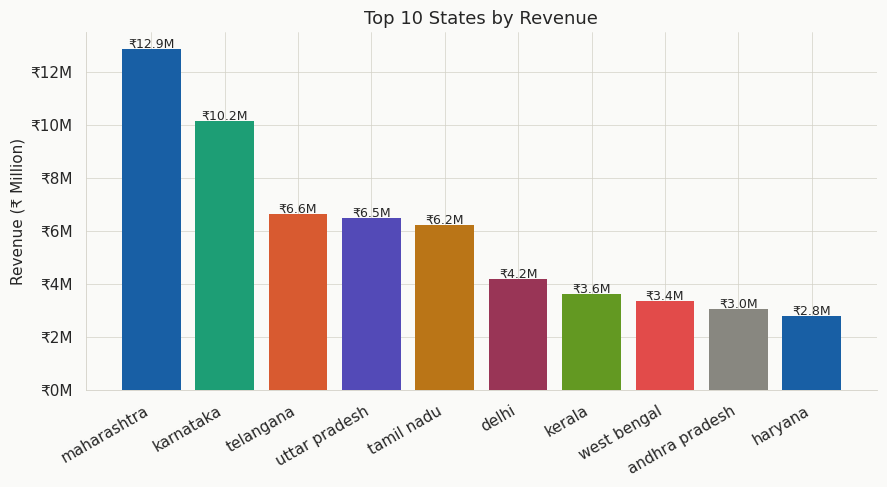

Top state: maharashtra — ₹12.86M


In [22]:
state_rev = df.groupby("state")["amount"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(state_rev.index, state_rev.values/1e6,
              color=PALETTE[:10], edgecolor="none")

for bar, val in zip(bars, state_rev.values):
    ax.text(bar.get_x()+bar.get_width()/2, val/1e6+0.05,
            f"₹{val/1e6:.1f}M", ha="center", fontsize=9)
    
ax.set_title("Top 10 States by Revenue")
ax.set_ylabel("Revenue (₹ Million)")
ax.set_xticklabels(state_rev.index, rotation=30, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"₹{x:.0f}M"))

plt.tight_layout()
plt.savefig("E:/Python/profitlens/src/output/amazon_sales/04_top_states.png", dpi=150, bbox_inches = "tight")
plt.show()

print(f'Top state: {state_rev.index[0]} — ₹{state_rev.iloc[0]/1e6:.2f}M')

### 4.5 Orders by Day of Week

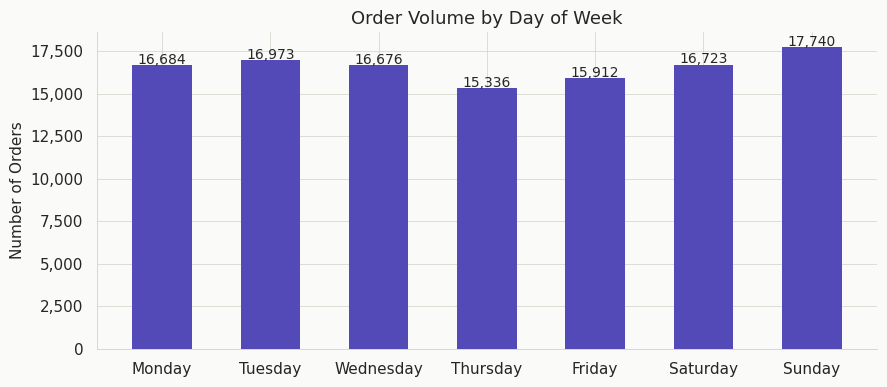

Pak day: Sunday (17,740 orders)


In [23]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = df["day_of_week"].value_counts().reindex(dow_order)

fig, ax = plt.subplots(figsize=(9,4))
ax.bar(dow.index, dow.values, color=PALETTE[3], edgecolor="none", width=0.55)
for i, val in enumerate(dow.values):
    ax.text(i, val+100, f"{val:,}", ha="center", fontsize=10)

ax.set_title("Order Volume by Day of Week")
ax.set_ylabel("Number of Orders")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f"{int(x):,}"))

plt.tight_layout()
plt.savefig("E:/Python/profitlens/src/output/amazon_sales/05_orders_by_day.png", dpi=150, bbox_inches = "tight")
plt.show()

print(f"Pak day: {dow.idxmax()} ({dow.max():,} orders)")


### 4.6 Fulfillment Method & Service Level

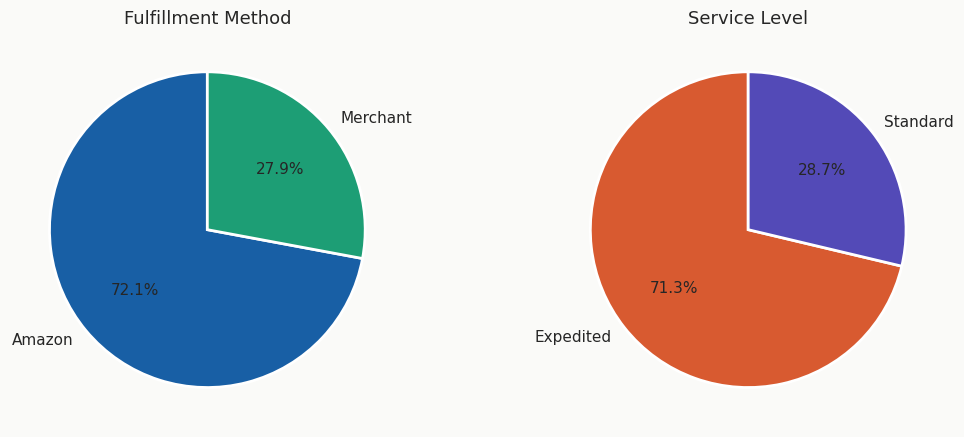

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ful = df['fulfillment'].value_counts()
axes[0].pie(ful.values, labels=ful.index, autopct='%1.1f%%',
            colors=[PALETTE[0], PALETTE[1]], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Fulfillment Method')

svc = df['service_level'].value_counts()
axes[1].pie(svc.values, labels=svc.index, autopct='%1.1f%%',
            colors=[PALETTE[2], PALETTE[3]], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Service Level')

plt.tight_layout()
plt.savefig("E:/Python/profitlens/src/output/amazon_sales/06_fulfillment_service.png", dpi=150, bbox_inches = "tight")
plt.show()

### 4.7 Revenue Heatmap - Category x Month

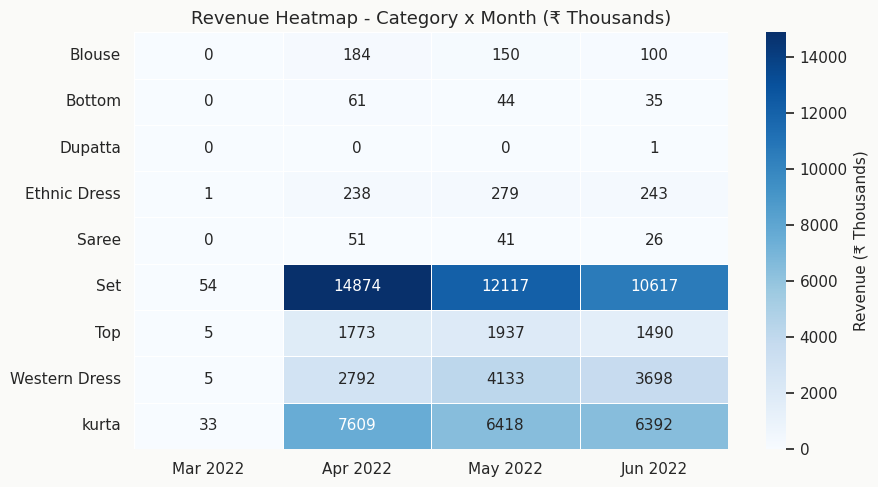

In [25]:
pivot = df.pivot_table(index="category", columns="month", values="amount", aggfunc="sum", fill_value=0)
pivot.columns = ["Mar 2022", "Apr 2022", "May 2022", "Jun 2022"]

fig, ax = plt.subplots(figsize=(9,5))
sns.heatmap(pivot/1e3, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5, linecolor="white", ax=ax,
            cbar_kws={"label": "Revenue (₹ Thousands)"})
ax.set_title("Revenue Heatmap - Category x Month (₹ Thousands)")
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig("E:/Python/profitlens/src/output/amazon_sales/07_category_month_heatmap.png", dpi=150, bbox_inches = "tight")
plt.show()

### 4.8 B2B vs B2C

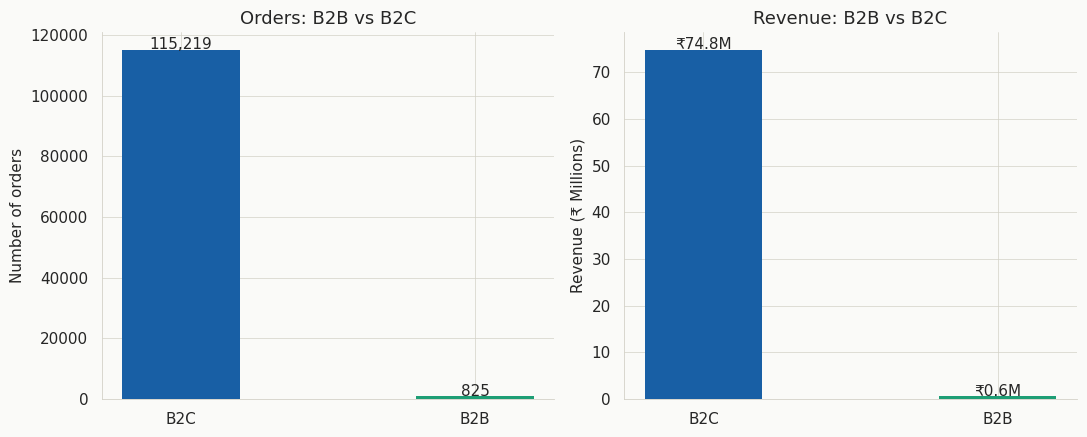

B2B orders: 0.7% of total orders


In [26]:
b2b_orders = df.groupby("B2B")["order_id"].count().rename({True:"B2B", False:"B2C"})
b2b_revenue = df.groupby("B2B")["amount"].sum().rename({True:"B2B", False:"B2C"})

fig, axes = plt.subplots(1, 2, figsize = (11, 4.5))

axes[0].bar(b2b_orders.index, b2b_orders.values, color=[PALETTE[0], PALETTE[1]], edgecolor="none", width=0.4)

for i, val in enumerate(b2b_orders.values):
    axes[0].text(i, val+200, f"{val:,}", ha="center", fontsize=11)
    
axes[0].set_title("Orders: B2B vs B2C")
axes[0].set_ylabel("Number of orders")
axes[0].yaxis.set_minor_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))

axes[1].bar(b2b_revenue.index, b2b_revenue.values/1e6, color=[PALETTE[0], PALETTE[1]], edgecolor="none", width=0.4)

for i, val in enumerate(b2b_revenue.values):
    axes[1].text(i, val/1e6+0.1, f"₹{val/1e6:.1f}M", ha="center", fontsize=11)

axes[1].set_title("Revenue: B2B vs B2C")
axes[1].set_ylabel("Revenue (₹ Millions)")
axes[1].yaxis.set_minor_formatter(mticker.FuncFormatter(lambda x,_: f"₹{x:.0f}M"))

plt.tight_layout()
plt.savefig("E:/Python/profitlens/src/output/amazon_sales/08_b2b_vs_b2c.png", dpi=150, bbox_inches = "tight")
plt.show()

b2b_pct = df["B2B"].sum()/len(df)*100
print(f"B2B orders: {b2b_pct:.1f}% of total orders")

### 4.9 Order Amount Distribution

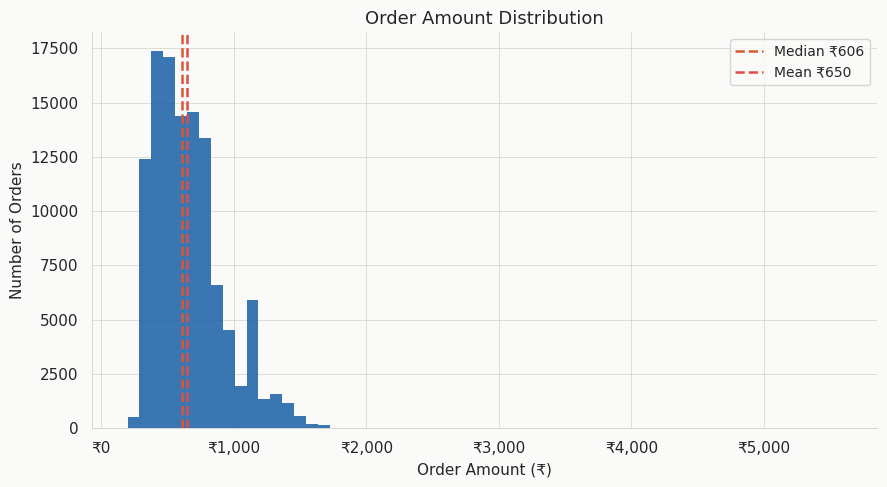

Median order value: ₹606
Mean order value: ₹650
Max order value: ₹5584


In [27]:
fix, ax = plt.subplots(figsize=(9,5))
ax.hist(df[df["amount"]>0]["amount"], bins=60, color=PALETTE[0], edgecolor="none", alpha=0.85)
ax.axvline(df["amount"].median(), color=PALETTE[2], linewidth=1.8, linestyle="--", 
           label=f"Median ₹{df["amount"].median():.0f}")
ax.axvline(df["amount"].mean(), color=PALETTE[7], linewidth=1.8, linestyle="--",
           label=f"Mean ₹{df["amount"].mean():.0f}")

ax.legend(fontsize=10)
ax.set_title("Order Amount Distribution")
ax.set_xlabel("Order Amount (₹)")
ax.set_ylabel("Number of Orders")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"₹{int(x):,}"))

plt.tight_layout()
plt.savefig("E:/Python/profitlens/src/output/amazon_sales/09_amount_distribution.png", dpi=150, bbox_inches = "tight")
plt.show()

print(f"Median order value: ₹{df["amount"].median():.0f}")
print(f"Mean order value: ₹{df["amount"].mean():.0f}")
print(f"Max order value: ₹{df["amount"].max():.0f}")